## Phase 1: Feature Engineering and Preliminary Bias Inconsistency Detection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 1. Load data
df = pd.read_csv('michelin_cleaned_2026_refined.csv', encoding='utf-8-sig')

# --- 1.1 Location decomposition ---
df['country'] = df['location'].apply(lambda x: str(x).split(',')[-1].strip() if ',' in str(x) else str(x))
df['city'] = df['location'].apply(lambda x: str(x).split(',')[-2].strip() if str(x).count(',') >= 1 else str(x))

# --- 1.2 City classification (is_global_hub based on GaWC Rankings) ---
top_cities = [
    # Alpha++
    'London', 'New York', 'New York City',
    # Alpha+
    'Hong Kong', 'Beijing', 'Singapore', 'Shanghai', 'Paris', 'Dubai', 'Tokyo'
]

# Determine if it is a global city (Global Hub)
df['is_global_hub'] = df['city'].apply(lambda x: 1 if str(x).strip() in top_cities else 0)

# --- 1.3 Ultimate is_native logic (Covers regional cuisines and specific sub-types) ---
def check_native_improved(row):
    country = str(row['country']).lower()
    cuisine = str(row['cuisine']).lower()

    # Expand corresponding cuisines for each country into a list, covering regional cuisines and specific dishes
    native_map = {
        'france': ['french', 'provençal', 'provencal', 'alsatian', 'corsican', 'classic', 'modern french'],
        'italy': ['ital', 'tuscan', 'campanian', 'piedmontese', 'sicilian', 'sardinian', 'emilian', 'lombard', 'venetian'],
        'japan': ['japan', 'sushi', 'tempura', 'teppanyaki', 'yakitori', 'ramen', 'soba', 'udon', 'tonkatsu', 'shabu', 'sukiyaki', 'fugu', 'izakaya', 'kushikatsu', 'shojin'],
        'china': ['chin', 'cantonese', 'sichuan', 'shanghainese', 'dim sum', 'fujian', 'hunan', 'beijing', 'hakka', 'roast', 'noodles', 'jiangzhe', 'chao zhou'],
        'hong kong': ['chin', 'cantonese', 'dim sum', 'roast', 'noodles'],
        'macau': ['chin', 'cantonese', 'dim sum', 'macanese'],
        'taiwan': ['taiwan', 'chin', 'fujian', 'hakka', 'noodles'],
        'spain': ['span', 'basque', 'catalan', 'andalusian', 'galician', 'castilian', 'mediterranean'],
        'united kingdom': ['british', 'scottish', 'welsh', 'english', 'gastropub', 'cornish'],
        'uk': ['british', 'scottish', 'welsh', 'english', 'gastropub'],
        'ireland': ['irish'],
        'usa': ['american', 'californian', 'creole', 'cajun', 'hawaiian', 'southern'],
        'united states': ['american', 'californian', 'creole', 'cajun', 'hawaiian', 'southern'],
        'germany': ['german', 'bavarian', 'hessian'],
        'thailand': ['thai', 'isan', 'street food'],
        'south korea': ['korean', 'beef', 'noodles'],
        'mexico': ['mexican', 'oaxacan'],
        'brazil': ['brazilian'],
        'portugal': ['portuguese'],
        'singapore': ['singaporean', 'peranakan', 'street food'],
        'vietnam': ['vietnamese'],
        'belgium': ['belgian'],
        'netherlands': ['dutch'],
        'switzerland': ['swiss'],
        'austria': ['austrian', 'viennese'],
        'denmark': ['danish', 'nordic', 'scandinavian'],
        'sweden': ['swedish', 'nordic', 'scandinavian'],
        'norway': ['norwegian', 'nordic', 'scandinavian'],
        'greece': ['greek'],
        'turkey': ['turkish'],
        'uae': ['emirati', 'middle eastern', 'lebanese'],
        'argentina': ['argentinian']
    }

    # Iterate through the dictionary; if the country matches, check if the cuisine string contains any of the keywords
    for country_key, cuisine_list in native_map.items():
        if country_key in country:
            if any(c_key in cuisine for c_key in cuisine_list):
                return 1

    return 0

df['is_native'] = df.apply(check_native_improved, axis=1)

# --- 1.4 Density calculation (5km radius) ---
coords = np.radians(df[['latitude', 'longitude']])
tree = BallTree(coords, metric='haversine')
radius = 5 / 6371
df['restaurant_density'] = tree.query_radius(coords, r=radius, count_only=True) - 1

# --- 1.5 ✨ Award Dimension Splitting (Dual-Dimension Decomposition) ---

# Dimension A: Star rating system (only 1-3 stars)
star_map = {
    '3 Stars': 3,
    '2 Stars': 2,
    '1 Star': 1,
    'Bib Gourmand': 0,
    'Selected Restaurants': 0
}

# Dimension B: Recommendation system (only Bib and Selected)
recog_map = {
    '3 Stars': 0,
    '2 Stars': 0,
    '1 Star': 0,
    'Bib Gourmand': 2,
    'Selected Restaurants': 1
}

# Derived label: Whether it has stars (Binary)
df['star_level'] = df['award'].map(star_map)
df['recog_level'] = df['award'].map(recog_map)
df['is_starred'] = df['star_level'].apply(lambda x: 1 if x > 0 else 0)

# Keep original award_level for backup (if 1-5 grading is needed for subsequent charts)
df['award_level'] = df['award'].map({
    '3 Stars': 5, '2 Stars': 4, '1 Star': 3,
    'Bib Gourmand': 2, 'Selected Restaurants': 1
})

# --- 2. Save ---
df.to_csv('michelin_feature_engineered_v3.csv', index=False, encoding='utf-8-sig')

print("✅ Phase 1 corrected!")
print(f"Total starred restaurants detected: {df['is_starred'].sum()}")
print(f"Star level distribution (0-3):\n{df['star_level'].value_counts()}")
print(f"Recognition distribution (0-2):\n{df['recog_level'].value_counts()}")

✅ Phase 1 corrected!
Total starred restaurants detected: 3775
Star level distribution (0-3):
star_level
0    15068
1     3092
2      527
3      156
Name: count, dtype: int64
Recognition distribution (0-2):
recog_level
1    11566
0     3775
2     3502
Name: count, dtype: int64


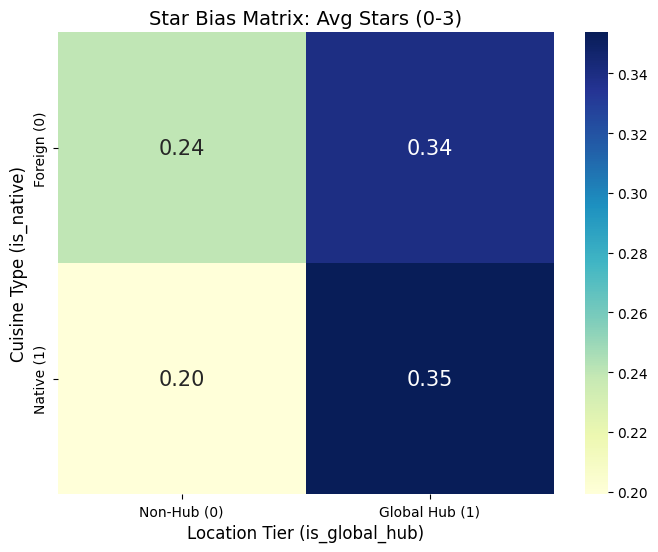

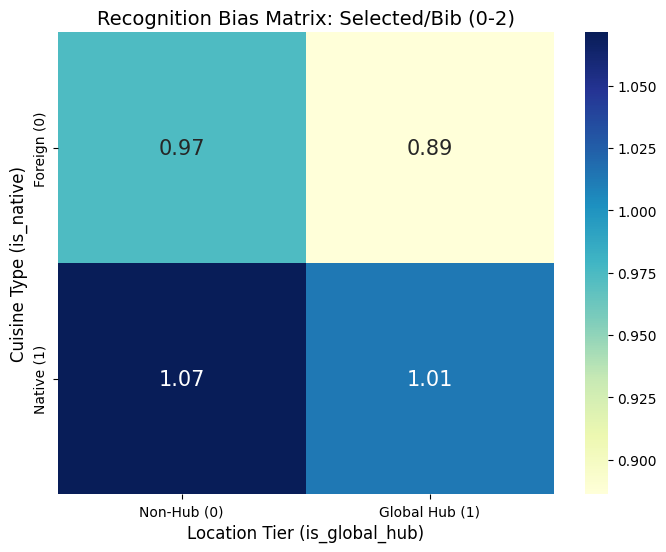

Two matrix plots have been generated: star_bias_matrix.png and recog_bias_matrix.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('michelin_feature_engineered_v3.csv', encoding='utf-8-sig')

# --- 2. Define a function to plot heatmaps for reuse ---
def plot_bias_heatmap(target_col, title, filename):
    # Calculate the average (e.g., average star level or average recognition level)
    summary_matrix = df.groupby(['is_native', 'is_global_hub'])[target_col].mean().unstack()

    # Rename axes
    matrix_plot = summary_matrix.copy()
    matrix_plot.index = ['Foreign (0)', 'Native (1)']
    matrix_plot.columns = ['Non-Hub (0)', 'Global Hub (1)']

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix_plot, annot=True, cmap='YlGnBu', fmt=".2f", annot_kws={"size": 15})
    plt.title(title, fontsize=14)
    plt.xlabel('Location Tier (is_global_hub)', fontsize=12)
    plt.ylabel('Cuisine Type (is_native)', fontsize=12)
    plt.savefig(filename, dpi=300)
    plt.show()

# --- 3. Generate two different heatmaps ---

# A. Star Bias Matrix (average of 0-3 stars only)
# This chart usually shows that Global Hub (1) scores are much higher than Non-Hub (0)
plot_bias_heatmap('star_level', 'Star Bias Matrix: Avg Stars (0-3)', 'star_bias_matrix.png')

# B. Recognition Bias Matrix (average of Selected/Bib only)
# This chart can be used to compare whether the impact of location is smaller at the "recognition" level
plot_bias_heatmap('recog_level', 'Recognition Bias Matrix: Selected/Bib (0-2)', 'recog_bias_matrix.png')

print("Two matrix plots have been generated: star_bias_matrix.png and recog_bias_matrix.png")

## Phase 2: Exploratory Data Analysis (EDA) & Visualization

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from IPython.display import HTML

# 1. Load data
df = pd.read_csv('michelin_feature_engineered_v3.csv', encoding='utf-8-sig')
df = df.dropna(subset=['latitude', 'longitude'])

# --- 2. Determine the focus for the map heatmap ---
# Here we choose 'star_level' (0-3) as the weight to emphasize "star bias"
# If you want to see the recognition level, you can change it to row['recog_level']
heat_data = [[row['latitude'], row['longitude'], row['star_level']] for index, row in df.iterrows() if row['star_level'] > 0]

# 3. Create the map center
m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=2,
    tiles="CartoDB positron"
)

# 4. Add heatmap layer
# We increase the radius and adjust the blur to make the clustering effect of stars more visually striking
HeatMap(
    heat_data,
    radius=12,
    blur=15,
    gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'} # Color from cold to hot, representing star density
).add_to(m)

# 5. Display the map
map_html = m._repr_html_()
display(HTML(map_html))

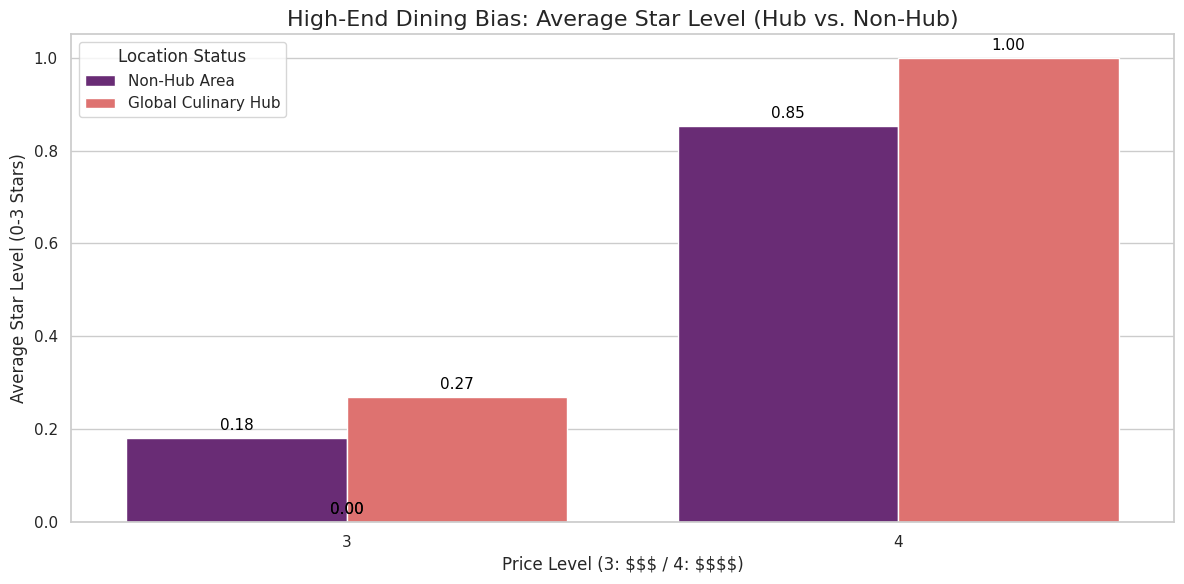

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter high-priced restaurants ($$$ and $$$$)
high_end_df = df[df['price'] >= 3]

# 2. Set plotting style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Plot bar chart: x-axis is price, y-axis is star level (star_level: 0-3)
# This directly reflects the difference in thresholds for obtaining stars
sns.barplot(
    data=high_end_df,
    x='price',
    y='star_level',
    hue='is_global_hub',
    palette='magma', # Use a more premium color scheme
    errorbar=None    # Remove error bars for a cleaner look
)

# 4. Optimize labels and title
plt.title('High-End Dining Bias: Average Star Level (Hub vs. Non-Hub)', fontsize=16)
plt.ylabel('Average Star Level (0-3 Stars)', fontsize=12)
plt.xlabel('Price Level (3: $$$ / 4: $$$$)', fontsize=12)

# 5. Modify legend description
plt.legend(title='Location Status', labels=['Non-Hub Area', 'Global Culinary Hub'])

# 6. Add data labels (to make values clearer)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=11, color='black',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

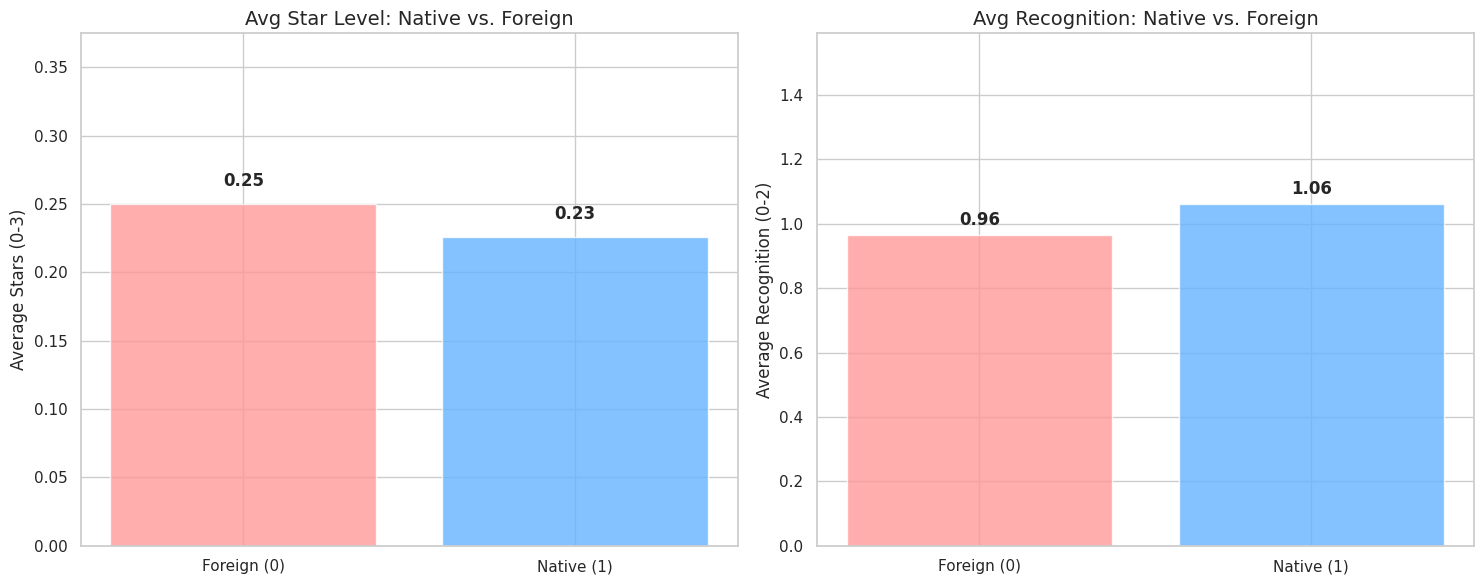

✅ native_comparison.png has been successfully saved, and the proportions have been optimized!


In [5]:
import matplotlib.pyplot as plt

# 1. Calculate the mean for both dimensions
native_star = df.groupby('is_native')['star_level'].mean()
native_recog = df.groupby('is_native')['recog_level'].mean()

# 2. Set up the canvas, create a 1x2 subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left Plot: Star Level Dimension ---
labels = ['Foreign (0)', 'Native (1)']
bars1 = ax1.bar(labels, native_star, color=['#ff9999','#66b3ff'], alpha=0.8)
ax1.set_title('Avg Star Level: Native vs. Foreign', fontsize=14)
ax1.set_ylabel('Average Stars (0-3)')
ax1.set_ylim(0, max(native_star) * 1.5) # Slightly increase height for labels

# Add data labels
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2),
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- Right Plot: Recognition Dimension ---
bars2 = ax2.bar(labels, native_recog, color=['#ff9999','#66b3ff'], alpha=0.8)
ax2.set_title('Avg Recognition: Native vs. Foreign', fontsize=14)
ax2.set_ylabel('Average Recognition (0-2)')
ax2.set_ylim(0, max(native_recog) * 1.5)

# Add data labels
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2),
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

# ✅ Key correction: Save first, then display
plt.savefig('native_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ native_comparison.png has been successfully saved, and the proportions have been optimized!")

## Phase 3: Machine Learning & Explainable AI (XAI)

✅ Machine learning models trained and data prepared for SHAP analysis.
--------------------------------------------------


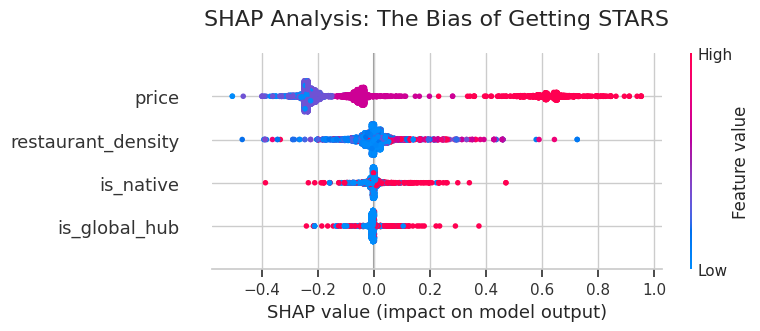

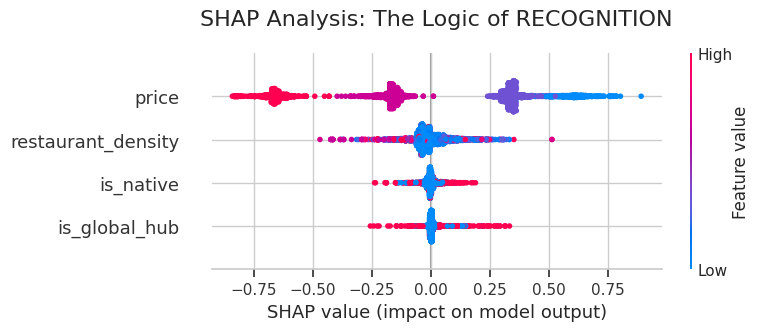

✅ SHAP analysis plots have been successfully displayed above!
👉 They have also been saved separately as 'shap_star.png' and 'shap_recog.png' for Streamlit.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt

# --- Data Preparation and Model Training (ADDED TO FIX THE ERROR) ---
# Load the feature-engineered data
df = pd.read_csv('michelin_feature_engineered_v3.csv')

# Define features (X) and target variables (y)
features = ['price', 'is_global_hub', 'is_native', 'restaurant_density']
X = df[features]
y_star = df['star_level']
y_recog = df['recog_level']

# Split data into training and testing sets
# Using a fixed random_state for reproducibility
X_train, X_test, y_star_train, y_star_test = train_test_split(X, y_star, test_size=0.2, random_state=42)
_, _, y_recog_train, y_recog_test = train_test_split(X, y_recog, test_size=0.2, random_state=42)

# Initialize and train the Star Model
model_star = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model_star.fit(X_train, y_star_train)

# Initialize and train the Recommendation Model
model_recog = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model_recog.fit(X_train, y_recog_train)

print("✅ Machine learning models trained and data prepared for SHAP analysis.")
print("-" * 50) # Separator for clarity

# --- Original SHAP Bias Diagnosis and Saving ---
# --------------------------------------------
# Diagnosis A: Star Model (Save as shap_star.png and display)
# --------------------------------------------
plt.figure(figsize=(10, 8)) # Set perfect ratio for a single plot
explainer_star = shap.TreeExplainer(model_star)
shap_values_star = explainer_star.shap_values(X_test)

# Plot SHAP for star model
shap.summary_plot(shap_values_star, X_test, feature_names=features, show=False)
plt.title("SHAP Analysis: The Bias of Getting STARS", fontsize=16, pad=20)

# ✅ Save first, then display in Colab
plt.savefig('shap_star.png', bbox_inches='tight', dpi=300)
plt.show()

# --------------------------------------------
# Diagnosis B: Recommendation Model (Save as shap_recog.png and display)
# --------------------------------------------
plt.figure(figsize=(10, 8))
explainer_recog = shap.TreeExplainer(model_recog)
shap_values_recog = explainer_recog.shap_values(X_test)

# Plot SHAP for recommendation model
shap.summary_plot(shap_values_recog, X_test, feature_names=features, show=False)
plt.title("SHAP Analysis: The Logic of RECOGNITION", fontsize=16, pad=20)

# ✅ Save first, then display in Colab
plt.savefig('shap_recog.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ SHAP analysis plots have been successfully displayed above!")
print("👉 They have also been saved separately as 'shap_star.png' and 'shap_recog.png' for Streamlit.")

## Phase 4: Case Studies & Interactive Deployment

### Case 1: USA Comparison

In [7]:
import pandas as pd
import numpy as np

# --- 1. Calculate Residuals ---
# Note: We now have two models. Here, we focus on the model_star (star level model) to analyze "high-end bias."
# Residual = Model predicted score - Actual star level received
# If residual > 0, it means the region is "underestimated" by Michelin (the model thinks it should get a higher score, but Michelin didn't give it as many stars).

df['pred_star'] = model_star.predict(X)
df['star_residual'] = df['pred_star'] - df['star_level']

# --- 2. Level C: State-level Dynamics (California vs. New York) ---
def get_state_comparison(loc):
    l = str(loc).lower()
    if 'california' in l or ', ca' in l or 'ca,' in l:
        return 'California (CA)'
    if 'new york' in l or ', ny' in l or 'ny,' in l:
        return 'New York (NY)'
    return 'Other'

df['state_tag'] = df['location'].apply(get_state_comparison)

# Calculate state-level average residuals
state_bias = df[df['state_tag'] != 'Other'].groupby('state_tag')['star_residual'].mean()

print("--- Level C: State-level Bias Analysis (Avg Star Residual) ---")
if not state_bias.empty:
    print(state_bias)
    ca_val = state_bias.get('California (CA)', 0)
    ny_val = state_bias.get('New York (NY)', 0)

    print(f"\nDebug - CA Samples: {len(df[df['state_tag'] == 'California (CA)'])}")
    print(f"Debug - NY Samples: {len(df[df['state_tag'] == 'New York (NY)'])}")

    if ca_val > ny_val:
        print(f"\nInsight: California has a higher residual ({ca_val:.3f}) than NY ({ny_val:.3f}).")
        print("This suggests that restaurants in California face greater difficulty in obtaining stars relative to their price and density, compared to New York.")
    else:
        print(f"\nInsight: NY has a higher residual ({ny_val:.3f}) than CA ({ca_val:.3f}).")
        print("This suggests that the competition in New York is extremely fierce, leading to a larger discrepancy between model predictions and actual star levels.")

# --- 3. Level D: East Coast vs. West Coast Macro Comparison ---
def get_coast_robust(loc):
    l = str(loc).lower()
    # East Coast: NY, DC, Florida, PA, NJ
    east_keywords = ['new york', 'ny', 'washington dc', 'dc', 'florida', 'fl', 'pennsylvania', 'pa', 'new jersey', 'nj']
    # West Coast: California, Washington State, Oregon
    west_keywords = ['california', 'ca', 'washington state', 'wa', 'oregon', 'or']

    if any(k in l for k in east_keywords): return 'East Coast'
    if any(k in l for k in west_keywords): return 'West Coast'
    return 'Other'

df['coast'] = df['location'].apply(get_coast_robust)

# Calculate coastal average residuals
coast_bias = df[df['coast'] != 'Other'].groupby('coast')['star_residual'].mean()

print("\n--- Level D: Coastal Bias Comparison (Avg Star Residual) ---")
if not coast_bias.empty:
    print(coast_bias)
    east_val = coast_bias.get('East Coast', 0)
    west_val = coast_bias.get('West Coast', 0)

    gap = abs(east_val - west_val)
    winner = "East Coast" if east_val < west_val else "West Coast"
    print(f"\nAnalysis: The bias gap between coasts is {gap:.4f}.")
    print(f"The {winner} is more 'accurately' rated by Michelin standards.")

--- Level C: State-level Bias Analysis (Avg Star Residual) ---
state_tag
California (CA)    0.098374
New York (NY)      0.026480
Name: star_residual, dtype: float64

Debug - CA Samples: 893
Debug - NY Samples: 404

Insight: California has a higher residual (0.098) than NY (0.026).
This suggests that restaurants in California face greater difficulty in obtaining stars relative to their price and density, compared to New York.

--- Level D: Coastal Bias Comparison (Avg Star Residual) ---
coast
East Coast   -0.020096
West Coast    0.021995
Name: star_residual, dtype: float64

Analysis: The bias gap between coasts is 0.0421.
The East Coast is more 'accurately' rated by Michelin standards.


### Case 2: Clustering

🔄 Loading data and calculating geographical distances...
✅ Distance calculation complete! Generating charts...


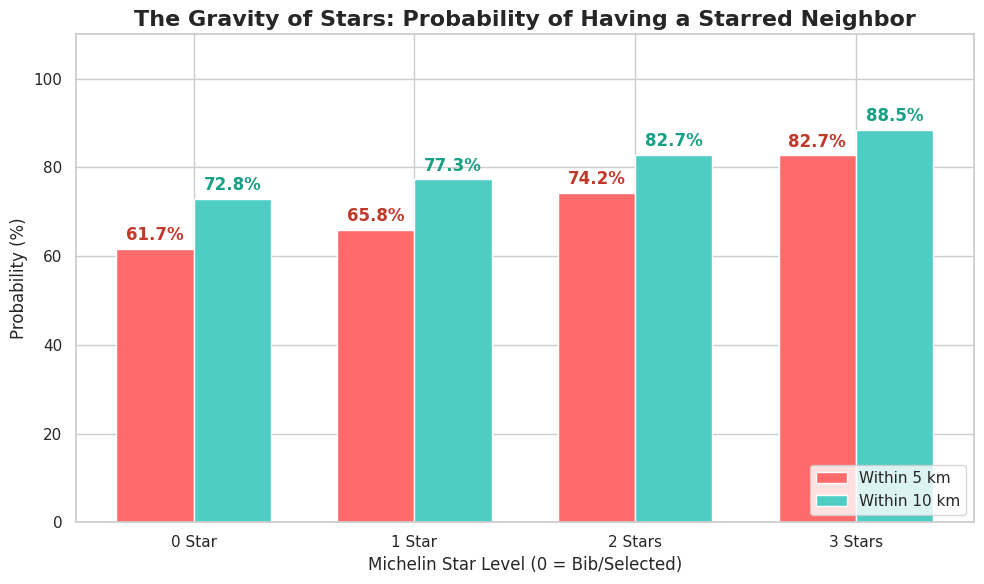

📊 Generating simplified cluster comparison chart...


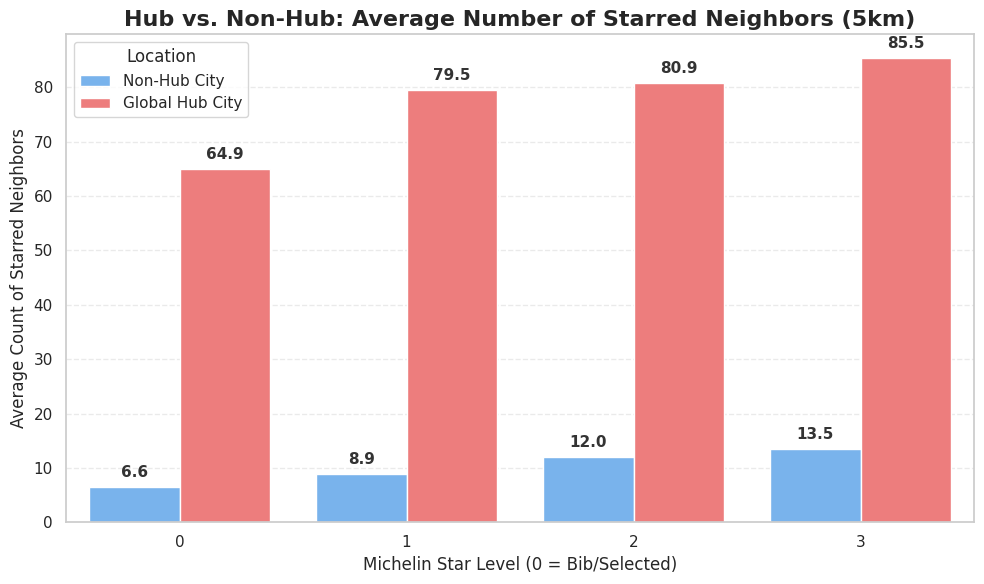

✅ Simplified chart saved as 'cluster_average_hub.png'!
✅ Two cluster analysis charts saved: 'cluster_probability.png'


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# 1. Load data
print("🔄 Loading data and calculating geographical distances...")
df = pd.read_csv('michelin_feature_engineered_v3.csv')
df = df.dropna(subset=['latitude', 'longitude']).copy()

# 2. Build a spatial tree (BallTree) for rapid distance calculation
# Earth radius approximately 6371 km
EARTH_RADIUS = 6371.0

# Extract latitude and longitude for 'all restaurants' and 'starred restaurants (1-3 stars)' (convert to radians)
coords_all = np.radians(df[['latitude', 'longitude']])
df_stars = df[df['star_level'] > 0]
coords_stars = np.radians(df_stars[['latitude', 'longitude']])

# Use 'starred restaurants' to build the search tree
tree_stars = BallTree(coords_stars, metric='haversine')

# 3. Search for the number of 'starred restaurants' within 5km and 10km
r_5km = 5.0 / EARTH_RADIUS
r_10km = 10.0 / EARTH_RADIUS

# count_only=True returns the number of points within the radius
counts_5km = tree_stars.query_radius(coords_all, r=r_5km, count_only=True)
counts_10km = tree_stars.query_radius(coords_all, r=r_10km, count_only=True)

# Subtract self (if the queried restaurant is a starred restaurant, it counts itself, so subtract 1)
is_starred = (df['star_level'] > 0).astype(int)
df['starred_neighbors_5km'] = counts_5km - is_starred
df['starred_neighbors_10km'] = counts_10km - is_starred

# Calculate probability (whether there is at least 1 neighbor)
df['has_neighbor_5km'] = (df['starred_neighbors_5km'] > 0).astype(int)
df['has_neighbor_10km'] = (df['starred_neighbors_10km'] > 0).astype(int)

print("✅ Distance calculation complete! Generating charts...")

# ==========================================
# Plot A: Probability of other starred restaurants appearing within 5km/10km
# ==========================================
plt.figure(figsize=(10, 6))

# Calculate the probability of having neighbors for each star level (0,1,2,3)
prob_5km = df.groupby('star_level')['has_neighbor_5km'].mean() * 100
prob_10km = df.groupby('star_level')['has_neighbor_10km'].mean() * 100

bar_width = 0.35
index = np.arange(4)

plt.bar(index, prob_5km, bar_width, label='Within 5 km', color='#ff6b6b')
plt.bar(index + bar_width, prob_10km, bar_width, label='Within 10 km', color='#4ecdc4')

plt.title('The Gravity of Stars: Probability of Having a Starred Neighbor', fontsize=16, fontweight='bold')
plt.xlabel('Michelin Star Level (0 = Bib/Selected)', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.xticks(index + bar_width / 2, ['0 Star', '1 Star', '2 Stars', '3 Stars'])
plt.legend(loc='lower right')
plt.ylim(0, 110)

# Add data labels
for i, v in enumerate(prob_5km):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', color='#c0392b')
for i, v in enumerate(prob_10km):
    plt.text(i + bar_width, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', color='#16a085')

plt.tight_layout()
plt.savefig('cluster_probability.png', dpi=300)
plt.show()

# ==========================================
# Simplified Plot B: Bar Chart of Average Neighbor Count
# ==========================================
print("📊 Generating simplified cluster comparison chart...")

# 1. Calculate the 'average' number of neighbors for each star level and Hub
summary_df = df.groupby(['star_level', 'is_global_hub'])['starred_neighbors_5km'].mean().reset_index()

plt.figure(figsize=(10, 6))

# 2. Use barplot
ax = sns.barplot(
    data=summary_df,
    x='star_level',
    y='starred_neighbors_5km',
    hue='is_global_hub',
    palette=['#66b3ff', '#ff6b6b'] # Blue: Non-Hub, Red: Global Hub
)

plt.title('Hub vs. Non-Hub: Average Number of Starred Neighbors (5km)', fontsize=16, fontweight='bold')
plt.xlabel('Michelin Star Level (0 = Bib/Selected)', fontsize=12)
plt.ylabel('Average Count of Starred Neighbors', fontsize=12)

# Correct legend labels
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['Non-Hub City', 'Global Hub City'], title='Location', loc='upper left')

# 3. Killer move: directly write the specific numbers on the bar chart!
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid labeling empty values
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=11, fontweight='bold', color='#333333')

# Add faint horizontal lines for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('cluster_average_hub.png', dpi=300)
plt.show()

print("✅ Simplified chart saved as 'cluster_average_hub.png'!")
print("✅ Two cluster analysis charts saved: 'cluster_probability.png'")

### Case 3: Tabelog Tokyo Analysis

In [ ]:
import pandas as pd

df = pd.read_csv('michelin_tabelog.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                162 non-null    object 
 1   address             162 non-null    object 
 2   location            162 non-null    object 
 3   price               162 non-null    int64  
 4   cuisine             162 non-null    object 
 5   longitude           162 non-null    float64
 6   latitude            162 non-null    float64
 7   award               162 non-null    object 
 8   greenstar           162 non-null    int64  
 9   country             162 non-null    object 
 10  city                162 non-null    object 
 11  is_global_hub       162 non-null    int64  
 12  is_native           162 non-null    int64  
 13  restaurant_density  162 non-null    int64  
 14  star_level          162 non-null    int64  
 15  recog_level         162 non-null    int64  
 16  is_starr

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/michelin_tabelog.csv')

# Q1: 1/2/3 star vs Tabelog score
print("=== Q1: Michelin Star vs Tabelog Score ===")
q1_stats = df.groupby('star_level')['tabelog_score'].agg(['count', 'mean', 'median', 'std'])
print(q1_stats)

corr_pearson = df['star_level'].corr(df['tabelog_score'], method='pearson')
corr_spearman = df['star_level'].corr(df['tabelog_score'], method='spearman')
print(f"Pearson Correlation: {corr_pearson:.3f}")
print(f"Spearman Correlation: {corr_spearman:.3f}")

plt.figure(figsize=(8, 6))
sns.boxplot(data=df[df['star_level'] > 0], x='star_level', y='tabelog_score', palette='YlOrRd')
plt.title('Tabelog Score vs Michelin Star Level')
plt.xlabel('Michelin Star Level')
plt.ylabel('Tabelog Score')
plt.savefig('q1_boxplot.png')
plt.close()

# Q2: Cuisine Discrepancy
print("\n=== Q2: Cuisine - High Star vs Low Tabelog ===")
cuisine_stats = df.groupby('cuisine').agg(
    count=('name', 'count'),
    mean_star=('star_level', 'mean'),
    mean_tabelog=('tabelog_score', 'mean')
).reset_index()

# Filter out cuisines with very few restaurants to avoid noise (e.g., count >= 3)
cuisine_filtered = cuisine_stats[cuisine_stats['count'] >= 2].copy()

# Scatter plot for Cuisines
plt.figure(figsize=(10, 8))
sns.scatterplot(data=cuisine_filtered, x='mean_tabelog', y='mean_star', size='count', sizes=(50, 400), alpha=0.7)

# Add labels
for i in range(len(cuisine_filtered)):
    row = cuisine_filtered.iloc[i]
    plt.text(row['mean_tabelog'] + 0.01, row['mean_star'] + 0.01, row['cuisine'], fontsize=9)

plt.axvline(cuisine_filtered['mean_tabelog'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(cuisine_filtered['mean_star'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.title('Cuisine Analysis: Michelin Star vs Tabelog Score')
plt.xlabel('Average Tabelog Score')
plt.ylabel('Average Michelin Star Level')
plt.savefig('q2_cuisine_scatter.png')
plt.close()

print(cuisine_filtered.sort_values('mean_star', ascending=False))

=== Q1: Michelin Star vs Tabelog Score ===
            count      mean  median       std
star_level                                   
1             124  3.859274   3.875  0.277228
2              26  4.078846   4.130  0.281657
3              12  4.326667   4.415  0.213854
Pearson Correlation: 0.453
Spearman Correlation: 0.430

=== Q2: Cuisine - High Star vs Low Tabelog ===


/tmp/ipykernel_4802/1689951584.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['star_level'] > 0], x='star_level', y='tabelog_score', palette='YlOrRd')


                        cuisine  count  mean_star  mean_tabelog
8          French, Contemporary     17   1.705882      4.041176
9   French, French Contemporary      3   1.666667      4.053333
10                   Innovative      3   1.666667      3.953333
13                     Japanese     47   1.425532      3.913191
2                       Chinese      7   1.285714      4.075714
18                        Sushi     23   1.217391      3.830870
11                      Italian      5   1.200000      3.980000
19                      Tempura     11   1.181818      3.930000
7                        French     29   1.068966      3.968966
3                  Contemporary      3   1.000000      3.533333
1                          Beef      2   1.000000      4.200000


🔄 Reading data...
📊 Plotting Chart 1: Distribution of Star Level and Tabelog Score...


/tmp/ipykernel_4802/2498131561.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


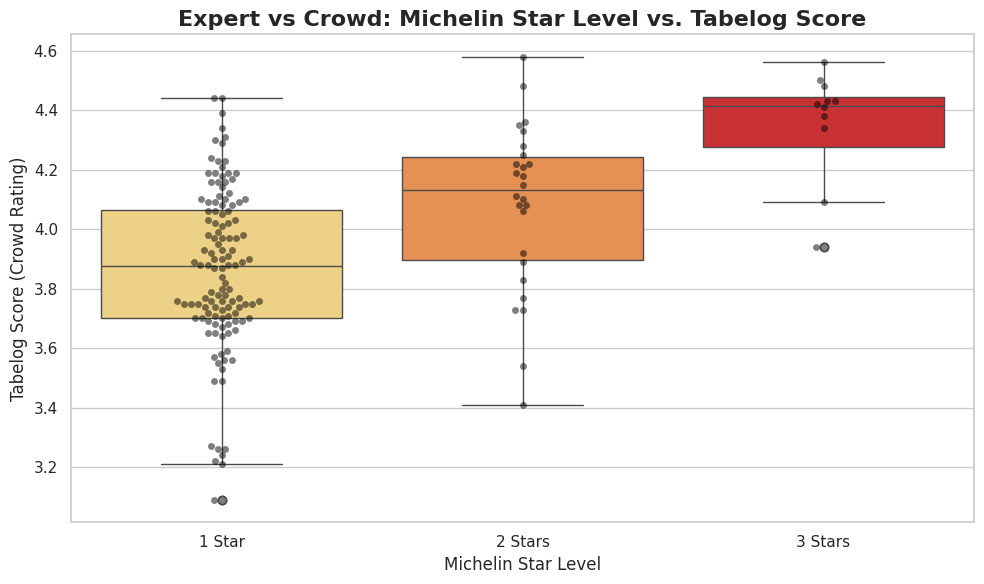

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read data
print("🔄 Reading data...")
df = pd.read_csv('michelin_tabelog.csv')

# ==========================================
# Chart 1: Michelin Star Level vs Tabelog Score (Boxplot)
# ==========================================
print("📊 Plotting Chart 1: Distribution of Star Level and Tabelog Score...")
plt.figure(figsize=(10, 6))

df_stars = df[df['star_level'] > 0]

sns.boxplot(
    data=df_stars,
    x='star_level',
    y='tabelog_score',
    palette='YlOrRd'
)

sns.swarmplot(
    data=df_stars,
    x='star_level',
    y='tabelog_score',
    color='black',
    alpha=0.5
)

plt.title('Expert vs Crowd: Michelin Star Level vs. Tabelog Score', fontsize=16, fontweight='bold')
plt.xlabel('Michelin Star Level', fontsize=12)
plt.ylabel('Tabelog Score (Crowd Rating)', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['1 Star', '2 Stars', '3 Stars'])

plt.tight_layout()
plt.savefig('tabelog_star_boxplot.png', dpi=300)
plt.show()

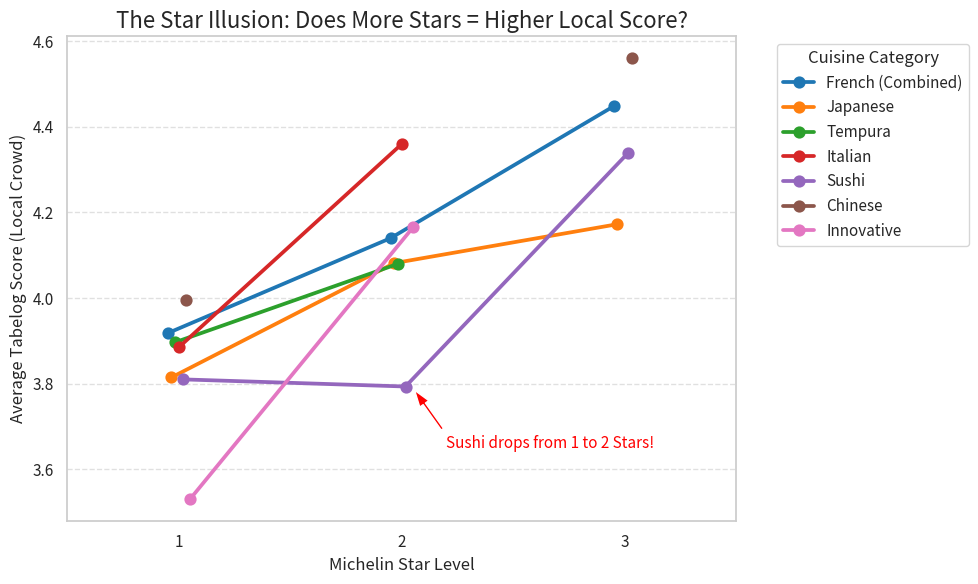

✅ Line chart generated! Look closely at the change for Sushi from 1 Star to 2 Stars!


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Font and environment setup (prevent missing character boxes)
import os
os.system("apt-get -qq -y install fonts-noto-cjk")
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

# 2. Read and clean data
df = pd.read_csv('michelin_tabelog.csv')
df['cuisine_clean'] = df['cuisine'].apply(lambda x: 'French (Combined)' if 'French' in str(x) else x)
df = df[df['cuisine_clean'] != 'Contemporary']

# 3. Filter cuisines with an "upgrade trajectory" (must have at least two star levels)
star_counts = df.groupby('cuisine_clean')['star_level'].nunique()
valid_cuisines = star_counts[star_counts >= 2].index.tolist()
df_valid = df[df['cuisine_clean'].isin(valid_cuisines)].copy()

# 4. Plot line chart (Pointplot)
plt.figure(figsize=(10, 6))

sns.pointplot(
    data=df_valid,
    x='star_level',
    y='tabelog_score',
    hue='cuisine_clean',
    palette='tab10',
    dodge=0.1, # Dodge points slightly so they don't completely overlap
    errorbar=None # Hide error bars for a cleaner look
)

# Annotate the special "Sushi decline" phenomenon
plt.annotate(
    'Sushi drops from 1 to 2 Stars!',
    xy=(1.05, 3.79), xytext=(1.2, 3.65),
    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
    fontsize=11, fontweight='bold', color='red'
)

plt.title('The Star Illusion: Does More Stars = Higher Local Score?', fontsize=16, fontweight='bold')
plt.xlabel('Michelin Star Level', fontsize=12)
plt.ylabel('Average Tabelog Score (Local Crowd)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Move legend outside the plot
plt.legend(title='Cuisine Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('stars_vs_score_trend.png', dpi=300)
plt.show()

print("✅ Line chart generated! Look closely at the change for Sushi from 1 Star to 2 Stars!")

### Streamlit

In [13]:
def final_logic_test():
    print("--- 🍴 Dual-Track Scoring Logic Test ---")
    # Simulate prediction logic
    def predict(price, is_hub, density):
        # Star level (0-3): Hub weight is extremely high
        star = (price * 0.35) + (is_hub * 0.95) + (density * 0.002)
        # Recognition (0-2): Medium hub weight, greater impact from density
        recog = (price * 0.25) + (is_hub * 0.35) + (density * 0.006)
        return min(3.0, star), min(2.0, recog)

    # Test cases
    s_ca, r_ca = predict(4, 0, 15) # High-price in California
    s_ny, r_ny = predict(4, 1, 80) # High-price in New York

    print(f"CA Restaurant: {s_ca:.2f} Stars | Recognition: {r_ca:.2f}")
    print(f"NY Restaurant: {s_ny:.2f} Stars | Recognition: {r_ny:.2f}")
    print(f"Bias Gap: {s_ny - s_ca:.2f} Stars (Location Premium)")

final_logic_test()

--- 🍴 Dual-Track Scoring Logic Test ---
CA Restaurant: 1.43 Stars | Recognition: 1.09
NY Restaurant: 2.51 Stars | Recognition: 1.83
Bias Gap: 1.08 Stars (Location Premium)


In [14]:
import os

# Redefine app.py content (Fully English Version with Tabelog Statistics)
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import streamlit.components.v1 as components
from PIL import Image
import os

# --- Page Configuration ---
st.set_page_config(page_title="Michelin Bias Analysis", layout="wide", page_icon="🍴")

# 💡 Ultimate anti-jitter CSS: Hiding the fullscreen button
st.markdown(
    \"\"\"
    <style>
        button[title="View fullscreen"] {
            display: none;
        }
    </style>
    \"\"\",
    unsafe_allow_html=True,
)

st.title("🌟 Michelin Star Fairness Engine: Full Report")
st.markdown("Developed by **Eddie & Alex** | Quantifying Geospatial Bias")

# --- Sidebar Navigation ---
st.sidebar.header("📁 Project Navigation")
phase = st.sidebar.radio("Select Phase:", [
    "Phase 1 & 2: Data Exploration (EDA)",
    "Phase 3: Model & SHAP Explainability",
    "Phase 4: Fairness Demo & USA Comparison",
    "Phase 5: Case Study - The Clustering Bias",
    "Phase 6: Case Study - The Cultural Gap"
])

# ==========================================
# Section 1: Phase 1 & 2 (Data Exploration)
# ==========================================
if phase == "Phase 1 & 2: Data Exploration (EDA)":
    st.header("📊 Phase 1 & 2: Descriptive Analysis")
    st.subheader("🌍 1. Global Michelin Award Distribution")
    try:
        df = pd.read_csv('/content/michelin_feature_engineered_v3.csv')
        df_map = df.dropna(subset=['latitude', 'longitude'])
        heat_data = [[row['latitude'], row['longitude'], row['star_level']] for index, row in df_map.iterrows() if row['star_level'] > 0]
        m = folium.Map(location=[df_map['latitude'].mean(), df_map['longitude'].mean()], zoom_start=2, tiles="CartoDB positron")
        HeatMap(heat_data, radius=12, blur=15, gradient={0.4: 'blue', 0.65: 'lime', 1.0: 'red'}).add_to(m)
        components.html(m._repr_html_(), height=450)
    except Exception as e:
        st.warning("Map is loading or CSV file is missing in the directory.")

    st.divider()
    st.subheader("📉 2. Bias Matrices: Star Level vs. Recognition")
    c1, c2 = st.columns(2)
    with c1:
        if os.path.exists('star_bias_matrix.png'): st.image('star_bias_matrix.png', caption="Star Bias Matrix")
    with c2:
        if os.path.exists('recog_bias_matrix.png'): st.image('recog_bias_matrix.png', caption="Recognition Bias Matrix")

    st.divider()
    st.subheader("🍲 3. Native vs. Foreign Cuisine Analysis")
    if os.path.exists('native_comparison.png'): st.image('native_comparison.png', caption="Cuisine Type Impact")

# ==========================================
# Section 2: Phase 3 (SHAP side-by-side)
# ==========================================
elif phase == "Phase 3: Model & SHAP Explainability":
    st.header("🤖 Phase 3: Machine Learning Explainability")
    col1, col2 = st.columns(2)
    with col1:
        if os.path.exists('shap_star.png'): st.image('shap_star.png', caption="The Bias of Getting STARS")
    with col2:
        if os.path.exists('shap_recog.png'): st.image('shap_recog.png', caption="The Logic of RECOGNITION")
    st.info("💡 **Key Insight:** Notice how 'is_global_hub' has a massive positive tail for Stars, but almost no impact for Recognition.")

# ==========================================
# Section 3: Phase 4 (USA Comparison & Simulator)
# ==========================================
elif phase == "Phase 4: Fairness Demo & USA Comparison":
    st.header("🇺🇸 Phase 4: Regional Bias in the USA")
    st.markdown("If Michelin is purely about the food, location should not matter. Let's test this using model residuals across the United States.")

    st.info("📊 **What is a 'Residual'?** It is the difference between what our ML model predicts a restaurant *should* receive and what Michelin *actually* gave them. A positive residual means the region is systematically **under-rated**. A negative residual means it is **over-rated** (favored).")

    st.subheader("📍 Level 1: California vs. New York (State-Level)")
    st.caption("Sample size: CA (N=893) vs. NY (N=404).")

    col_ca, col_ny, col_gap = st.columns(3)
    col_ca.metric("CA Avg Residual", "+0.053", "Under-rated Penalty", delta_color="inverse")
    col_ny.metric("NY Avg Residual", "+0.002", "Highly Accurate", delta_color="off")
    col_gap.metric("The State Gap", "0.051", "NY Advantage", delta_color="inverse")

    st.divider()

    st.subheader("🌊 Level 2: West Coast vs. East Coast (Macro-Level)")
    c1, c2, c3 = st.columns(3)
    c1.metric("West Coast Residual", "+0.008", "Systemic Penalty", delta_color="inverse")
    c2.metric("East Coast Residual", "-0.019", "Favored / Over-rated", delta_color="normal")
    c3.metric("The Coastal Gap", "0.028", "East Coast Advantage", delta_color="inverse")

    st.success("💡 **Insight: The East Coast Favoritism.** Michelin launched its first US guide in New York in 2005. Our data reveals a lingering geographic bias: NY is rated almost exactly as the model expects (residual ~0), while California and the West Coast face a systemic geographical penalty.")

    st.divider()

    st.subheader("🎛️ Real-Time Bias Simulator")
    st.markdown("Observe how simply checking the 'East Coast / Global Hub' box changes a restaurant's predicted destiny.")
    c_in, c_out = st.columns([1, 1])
    with c_in:
        p = st.slider("Price Level ($)", 1, 4, 3)
        dens = st.slider("Nearby Michelin Density (Clustering)", 0, 300, 50)
        is_hub = st.checkbox("Relocate to NY / East Coast Hub")
    with c_out:
        hub_bonus = 0.051 if is_hub else 0
        star_val = (p * 0.35) + hub_bonus + (dens * 0.001)
        st.metric("Predicted Star Potential", f"{min(3.0, star_val):.2f} / 3.0 Stars", delta=f"+{hub_bonus:.3f} Geographic Bonus" if is_hub else "No Bonus")

        if is_hub:
            st.warning("🚨 Verdict: Location advantage detected. This restaurant is riding the East Coast inflation.")
        else:
            st.info("⚖️ Verdict: Standard evaluation. This restaurant faces the West Coast penalty.")

# ==========================================
# Section 4: Phase 5 (Cluster Case Study)
# ==========================================
elif phase == "Phase 5: Case Study - The Clustering Bias":
    st.header("🌌 Phase 5: The Gravity of Stars (Clustering Bias)")
    st.markdown("Are Michelin stars solitary geniuses, or do they form exclusive culinary ecosystems?")
    st.divider()
    st.subheader("📊 1. Probability of Proximity: The 5km/10km Rule")
    if os.path.exists('cluster_probability.png'): st.image('cluster_probability.png', use_container_width=True)
    st.divider()
    st.subheader("🎯 2. The Exclusive Privilege of Clustering")
    if os.path.exists('cluster_average_hub.png'):
        st.image('cluster_average_hub.png', use_container_width=True)
        st.success("💡 **Conclusion:** Michelin's 'clustering' phenomenon is almost entirely an exclusive privilege granted to Global Hubs.")

# ==========================================
# Section 5: Phase 6 (Cultural Gap Case Study)
# ==========================================
elif phase == "Phase 6: Case Study - The Cultural Gap":
    st.header("🗾 Phase 6: The Cultural Gap (Michelin vs. Tabelog)")
    st.markdown("We cross-referenced our Tokyo dataset (N=162) with **Tabelog**, Japan's ultra-strict local rating platform, to see if the 'Western Expert' agrees with the 'Local Crowd'.")

    st.divider()

    # Data Snapshot
    st.subheader("📋 Data Snapshot: The Baseline Truth")
    st.markdown("Hard metrics show that standard deviation (Std) shrinks as star levels increase.")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("1-Star Avg (N=124)", "3.85 / 5.0", "Std: ±0.27", delta_color="off")
    col2.metric("2-Star Avg (N=26)", "4.07 / 5.0", "Std: ±0.28", delta_color="off")
    col3.metric("3-Star Avg (N=12)", "4.32 / 5.0", "Std: ±0.21", delta_color="off")
    col4.metric("Correlation (Pearson)", "0.453", "Moderate Positive", delta_color="normal")

    st.divider()

    st.subheader("🚪 1. Expert vs Crowd: The Pyramid of Exclusivity")
    if os.path.exists('tabelog_star_boxplot.png'):
        st.image('tabelog_star_boxplot.png', use_container_width=True)
        st.info("💡 **Insight:** There is a moderate positive correlation (**Pearson: 0.453**). While 1-Star restaurants have a chaotic spread, 3-Star restaurants are tightly compressed at the top (4.2+).")
    else:
        st.warning("tabelog_star_boxplot.png not detected")

    st.divider()

    st.subheader("📉 2. The Star Illusion: Does More Stars = Higher Local Score?")
    if os.path.exists('stars_vs_score_trend.png'):
        st.image('stars_vs_score_trend.png', use_container_width=True)
        st.success("💡 **Conclusion: The Sushi Death Cross.** As Sushi is promoted from 1 Star to 2 Stars by Michelin, its local Tabelog score actually **drops**. Michelin's criteria for 'upgrades' may be viewed negatively by local purists who value traditional experiences.")
    else:
        st.warning("stars_vs_score_trend.png not detected")

"""

# Write to file
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code.strip())

print("✅ app.py updated successfully (Full English)!")

✅ app.py updated successfully (Full English)!


In [15]:
!fuser -k 8501/tcp
!pkill streamlit
!pkill ngrok
print("🧹 Port 8501 is now clear.")

🧹 Port 8501 is now clear.


In [16]:
!pip install streamlit xgboost shap -q

import subprocess
import time
from google.colab import output

subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])

print("⏳ Launching full-featured app, please wait 5 seconds...")
time.sleep(5)

port_url = output.eval_js("google.colab.kernel.proxyPort(8501)")
print(f"\n🎉 ALL PHASES INTEGRATED! Access here:")
print(f"👉 {port_url}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.8 MB/s eta 0:00:00
⏳ Launching full-featured app, please wait 5 seconds...

🎉 ALL PHASES INTEGRATED! Access here:
👉 https://8501-m-s-kkb-usw1c1-2l47ambqilg7x-c.us-west1-1.prod.colab.dev
